# Airline Delay Project: Data Cleaning and EDA

**Question:** Which airlines, airports, routes, and departure periods have the most delays and cancellations, and what can we learn before building a pre-departure severe-delay model?

This notebook completes the cleaning explanation and full-year EDA for the 12 BTS files from 2025. The separate `02_feature_engineering.ipynb` explains transformations and the future ML handoff.

Run `python scripts/run_etl.py` from the project root first. It reads all raw files, refreshes the audit, applies the same cleaning functions used here, and saves monthly Parquet data. Then choose **Run All** in this notebook. The small raw preview below is a teaching example; reported totals and rates come from every flight, not this preview.

Libraries: pandas for tables, NumPy for calculations, Matplotlib and Seaborn for charts. PyArrow is only the storage engine behind pandas Parquet operations. No ML models are fitted in this stage.

## 1. Import the libraries and set the folders

In [1]:
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "airline-matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_FOLDER = Path.cwd()
if PROJECT_FOLDER.name == "notebooks":
    PROJECT_FOLDER = PROJECT_FOLDER.parent
if not (PROJECT_FOLDER / "PROJECT_PLAN.md").is_file():
    raise FileNotFoundError("Start Jupyter from the project root or notebooks folder.")
sys.path.insert(0, str(PROJECT_FOLDER))
from src.clean import clean_chunk, NUMERIC_COLUMNS, CODE_COLUMNS
from src.config import load_column_map, load_settings

from src.report_paths import TABLE_FOLDERS, table_path
TABLE_FOLDER = PROJECT_FOLDER / "reports" / "tables"
FIGURE_FOLDER = PROJECT_FOLDER / "reports" / "figures"
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)
missing_tables = [name for name in TABLE_FOLDERS if not table_path(TABLE_FOLDER, name).is_file()]
if missing_tables:
    raise FileNotFoundError(f"Run python scripts/run_etl.py first. Missing report tables: {missing_tables}")

settings = load_settings()
column_map = load_column_map()
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)

## A. Inspect the source before changing it

One source row represents a scheduled flight. The business key is flight date + airline + flight number + origin + destination + scheduled departure time. Source filename and the original one-based data-row number preserve traceability.

The audit checks every monthly file. It verifies dates and schema and counts exact and business-key duplicates. Month/date validation prevents a business key from silently recurring in a different monthly partition.

In [2]:
manifest = pd.read_csv(table_path(TABLE_FOLDER, "source_manifest"))
display(manifest[["expected_month", "row_count", "column_count", "min_flight_date",
                  "max_flight_date", "exact_duplicates_after_first", "business_key_duplicates_after_first"]])
print("Total source rows:", f"{manifest['row_count'].sum():,}")
print("Schema consistent:", manifest["schema_matches_reference"].all())

raw_path = PROJECT_FOLDER / "data/raw/bts/2025/bts_ontime_2025_01.csv"
raw_demo = pd.read_csv(raw_path, nrows=10_000, low_memory=False)
print("Teaching preview shape:", raw_demo.shape)
display(raw_demo.head())
raw_demo.info()

,expected_month,row_count,column_count,min_flight_date,max_flight_date,exact_duplicates_after_first,business_key_duplicates_after_first
0,1,539747,28,2025-01-01,2025-01-31,0,0
1,2,504884,28,2025-02-01,2025-02-28,0,0
2,3,600872,28,2025-03-01,2025-03-31,0,0
3,4,583950,28,2025-04-01,2025-04-30,0,0
4,5,605648,28,2025-05-01,2025-05-31,0,0
5,6,611575,28,2025-06-01,2025-06-30,0,0
6,7,631428,28,2025-07-01,2025-07-31,0,0
7,8,602378,28,2025-08-01,2025-08-31,0,0
8,9,562439,28,2025-09-01,2025-09-30,0,0
9,10,605844,28,2025-10-01,2025-10-31,0,0


Total source rows: 7,001,619
Schema consistent: True
Teaching preview shape: (10000, 28)


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1,JFK,LAX,...,0.0,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,10,LAX,JFK,...,0.0,330.0,290.0,274.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1002,MSN,CLT,...,0.0,141.0,125.0,91.0,708.0,20.0,0.0,0.0,0.0,0.0
3,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1004,PHL,LAS,...,0.0,339.0,331.0,306.0,2176.0,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1005,ORD,PHX,...,0.0,241.0,286.0,212.0,1440.0,0.0,0.0,44.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 10000 non-null  int64  
 1   QUARTER              10000 non-null  int64  
 2   MONTH                10000 non-null  int64  
 3   DAY_OF_MONTH         10000 non-null  int64  
 4   DAY_OF_WEEK          10000 non-null  int64  
 5   FL_DATE              10000 non-null  object 
 6   OP_UNIQUE_CARRIER    10000 non-null  object 
 7   OP_CARRIER_FL_NUM    10000 non-null  int64  
 8   ORIGIN               10000 non-null  object 
 9   DEST                 10000 non-null  object 
 10  CRS_DEP_TIME         10000 non-null  int64  
 11  DEP_TIME             9982 non-null   float64
 12  DEP_DELAY            9982 non-null   float64
 13  CRS_ARR_TIME         10000 non-null  int64  
 14  ARR_TIME             9979 non-null   float64
 15  ARR_DELAY            9968 non-null   

## B. Missing values: understand why they are missing

A high missing percentage does not automatically justify dropping a column. Missing cancellation codes are expected for flights that were not cancelled. Cancelled/diverted flights can lack actual arrival measurements. Cause fields describe reported delays; missing is not a measured zero.

We preserve these nulls in operational data. A completed, non-diverted flight with no arrival delay is flagged and cannot have a supervised target. We do not fill outcome values with a mean, median, or zero.

,column,observed_dtypes,null_count,null_percentage,unique_count
17,CANCELLATION_CODE,object,6898743,9.853068e-01,4
27,LATE_AIRCRAFT_DELAY,float64,5466981,7.808167e-01,1328
26,SECURITY_DELAY,float64,5466981,7.808167e-01,218
25,NAS_DELAY,float64,5466981,7.808167e-01,915
24,WEATHER_DELAY,float64,5466981,7.808167e-01,1141
23,CARRIER_DELAY,float64,5466981,7.808167e-01,1704
15,ARR_DELAY,float64,122135,1.744382e-02,1925
21,AIR_TIME,float64,122135,1.744382e-02,684
20,ACTUAL_ELAPSED_TIME,float64,122135,1.744382e-02,724
14,ARR_TIME,float64,104608,1.494054e-02,1440


,status,flights,dep_time_missing,arr_time_missing,arrival_delay_minutes_missing,air_time_minutes_missing,cancellation_code_missing,carrier_delay_minutes_missing
0,Cancelled,102876,98170,102876,102876,102876,0,102876
1,Completed: known outcome,6879484,0,0,0,0,6879484,5344846
2,Completed: unknown outcome,1,0,1,1,1,1,1
3,Diverted,19258,0,1731,19258,19258,19258,19258


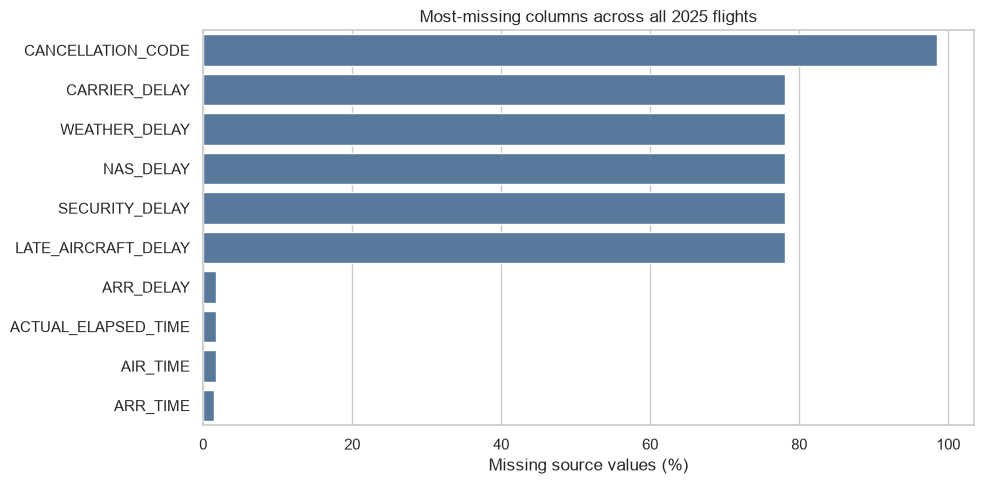

In [3]:
profile = pd.read_csv(table_path(TABLE_FOLDER, "column_profile"))
display(profile.sort_values("null_percentage", ascending=False))
missing_by_status = pd.read_csv(table_path(TABLE_FOLDER, "missingness_by_status"))
display(missing_by_status)

plot_missing = profile.nlargest(10, "null_percentage").copy()
plot_missing["missing_percent"] = plot_missing["null_percentage"] * 100
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_missing, y="column", x="missing_percent", color="#4C78A8")
plt.xlabel("Missing source values (%)")
plt.ylabel("")
plt.title("Most-missing columns across all 2025 flights")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "raw_missingness.png", dpi=160)
plt.show()

## C. Convert types and standardize labels

The following cells expose the basic pandas operations used by `src/clean.py`. A string such as `" aa "` would become `"AA"`, and a blank code becomes missing. The conversion audit tells us whether the supplied data actually needed these corrections.

`errors="coerce"` creates a null for unparseable text. We count those failures separately from original nulls; the production pipeline checks required values before saving. Dates are not guessed: the explicit format matches the BTS source.

In [4]:
typed_demo = raw_demo.rename(columns=column_map).copy()
for column in CODE_COLUMNS:
    typed_demo[column] = typed_demo[column].astype("string").str.strip().str.upper().replace("", pd.NA)
for column in NUMERIC_COLUMNS:
    typed_demo[column] = pd.to_numeric(typed_demo[column], errors="coerce")
typed_demo["flight_date"] = pd.to_datetime(
    typed_demo["flight_date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce"
)
display(typed_demo[["flight_date", "reporting_airline", "origin", "arrival_delay_minutes"]].head())
display(typed_demo[["flight_date", "reporting_airline", "arrival_delay_minutes"]].dtypes)

conversion_audit = pd.read_csv(table_path(TABLE_FOLDER, "conversion_audit"))
display(conversion_audit.groupby("check", as_index=False)["rows"].sum())

,flight_date,reporting_airline,origin,arrival_delay_minutes
0,2025-01-01,AA,JFK,-7.0
1,2025-01-01,AA,LAX,-47.0
2,2025-01-01,AA,MSN,20.0
3,2025-01-01,AA,PHL,-7.0
4,2025-01-01,AA,ORD,44.0


flight_date              datetime64[ns]
reporting_airline        string[python]
arrival_delay_minutes           float64
dtype: object

,check,rows
0,category_corrections,0
1,date_parse_failures,0
2,numeric_parse_failures,0


## D. Apply the cleaning rules and verify the result

An impossible nonpositive scheduled duration becomes missing with a flag. We retain its flight because other fields may still be useful. Clock values must contain whole hours/minutes; 2400 maps to midnight hour 0, while a value such as 1260 is invalid.

The arrival-delay target is **1 only above 60 minutes**, and **0 at or below 60**, for completed, non-diverted flights with a known arrival delay. Other rows keep a null target. Negative delay means early arrival, so it is retained.

In [5]:
clean_demo = clean_chunk(
    raw_demo, column_map, raw_path, 2025, 1,
    settings["target"]["severe_delay_minutes"],
    settings["features"]["departure_time_bands"],
)
assert len(clean_demo) == len(raw_demo)
assert clean_demo.loc[clean_demo["ml_target_eligible"].eq(0), "severe_delay"].isna().all()
display(clean_demo[["flight_date", "origin", "destination", "scheduled_elapsed_minutes",
                    "scheduled_elapsed_invalid", "cancelled", "diverted",
                    "arrival_delay_minutes", "severe_delay"]].head(10))

issues = pd.read_csv(table_path(TABLE_FOLDER, "data_quality_issues"))
display(issues.loc[issues["rows_affected"].gt(0)])
flags = pd.read_csv(table_path(TABLE_FOLDER, "flagged_row_samples"))
display(flags[["flight_date", "reporting_airline", "flight_number", "origin", "destination",
               "cancelled", "diverted", "raw_scheduled_elapsed_minutes",
               "scheduled_elapsed_minutes", "arrival_delay_minutes", "issue"]])

,flight_date,origin,destination,scheduled_elapsed_minutes,scheduled_elapsed_invalid,cancelled,diverted,arrival_delay_minutes,severe_delay
0,2025-01-01,JFK,LAX,381.0,0,0.0,0.0,-7.0,0
1,2025-01-01,LAX,JFK,330.0,0,0.0,0.0,-47.0,0
2,2025-01-01,MSN,CLT,141.0,0,0.0,0.0,20.0,0
3,2025-01-01,PHL,LAS,339.0,0,0.0,0.0,-7.0,0
4,2025-01-01,ORD,PHX,241.0,0,0.0,0.0,44.0,0
5,2025-01-01,COS,DFW,113.0,0,0.0,0.0,-5.0,0
6,2025-01-01,DFW,COS,114.0,0,0.0,0.0,-2.0,0
7,2025-01-01,CLT,STL,131.0,0,0.0,0.0,-6.0,0
8,2025-01-01,LGA,CLT,130.0,0,0.0,0.0,-8.0,0
9,2025-01-01,EGE,MIA,253.0,0,0.0,0.0,36.0,0


,issue,rows_affected
11,nonpositive_scheduled_elapsed_time,5
14,completed_missing_arrival_delay,1


,flight_date,reporting_airline,flight_number,origin,destination,cancelled,diverted,raw_scheduled_elapsed_minutes,scheduled_elapsed_minutes,arrival_delay_minutes,issue
0,2025-09-06,YX,5859,JFK,MVY,0.0,0.0,84.0,84.0,NaN,completed_missing_arrival_delay
1,2025-11-17,WN,1556,LAS,BUR,0.0,1.0,-99.0,NaN,NaN,nonpositive_scheduled_elapsed_time
2,2025-11-17,WN,3526,LAS,BUR,0.0,1.0,-67.0,NaN,NaN,nonpositive_scheduled_elapsed_time
3,2025-11-19,OO,3574,DTW,LEX,0.0,0.0,-60.0,NaN,218.0,nonpositive_scheduled_elapsed_time
4,2025-11-20,WN,32,HOU,DAL,0.0,1.0,-85.0,NaN,NaN,nonpositive_scheduled_elapsed_time
5,2025-12-21,WN,575,HOU,HRL,1.0,0.0,-61.0,NaN,NaN,nonpositive_scheduled_elapsed_time


### Decision on the six flagged records

Five scheduled durations are negative. Three belong to diverted flights and one to a cancelled flight. The fifth is completed OO 3574, DTW–LEX, 19 November, with a known 218-minute arrival delay. Its target remains valid; its duration is missing and flagged. A later training-fitted imputer can handle that predictor.

YX 5859, JFK–MVY, 6 September is marked completed/non-diverted but lacks an arrival delay. Keep the operational record and flag it; exclude it from the arrival-delay target. The raw values are preserved in the evidence table above.

No exact or business-key duplicate candidates were found, so no records were deleted. A future refresh stops if duplicate candidates appear, allowing investigation.

## E. Investigate extremes instead of removing them automatically

Read the 10 largest and 10 smallest arrival delays with airline, route, date, durations, and delay causes. As a consistency check, arrival delay minus departure delay should equal actual elapsed time minus scheduled elapsed time. This check supports a retention decision but cannot independently verify the reported event.

All records stay in the operational dataset. Quantiles below use all eligible flights. A mean much larger than the median indicates that the long right tail affects the average.

In [6]:
extremes = pd.read_csv(table_path(TABLE_FOLDER, "extreme_delay_review"))
display(extremes[["flight_date", "reporting_airline", "flight_number", "origin", "destination",
                  "departure_delay_minutes", "arrival_delay_minutes", "scheduled_elapsed_minutes",
                  "actual_elapsed_minutes", "elapsed_delay_identity_error"]])
distribution = pd.read_csv(table_path(TABLE_FOLDER, "delay_distribution"))
display(distribution)
print("Extreme records failing the duration/delay identity:",
      extremes["elapsed_delay_identity_error"].ne(0).sum())

,flight_date,reporting_airline,flight_number,origin,destination,departure_delay_minutes,arrival_delay_minutes,scheduled_elapsed_minutes,actual_elapsed_minutes,elapsed_delay_identity_error
0,2025-09-24,AA,797,MSN,DFW,4352.0,4336.0,153.0,137.0,0.0
1,2025-10-20,AA,1276,IAH,ORD,3475.0,3500.0,167.0,192.0,0.0
2,2025-02-24,AA,3063,SJU,PHL,3403.0,3407.0,250.0,254.0,0.0
3,2025-01-28,AA,2420,IAH,DFW,3298.0,3282.0,98.0,82.0,0.0
4,2025-03-24,AA,2241,RSW,CLT,3288.0,3275.0,123.0,110.0,0.0
5,2025-05-27,AA,1347,IAH,MIA,3205.0,3241.0,150.0,186.0,0.0
6,2025-10-16,AA,2163,BDL,ORD,3239.0,3240.0,162.0,163.0,0.0
7,2025-08-23,AA,1813,SDF,MIA,3164.0,3147.0,153.0,136.0,0.0
8,2025-02-21,AA,1502,MFE,DFW,3092.0,3103.0,100.0,111.0,0.0
9,2025-01-03,MQ,3373,MLU,DFW,2983.0,2955.0,103.0,75.0,0.0


,group,eligible_flights,mean,median,p90,p95,p99,minimum,maximum
0,All eligible flights,6879484,8.504504,-6.0,48.0,91.0,225.0,-128.0,4336.0


Extreme records failing the duration/delay identity: 0


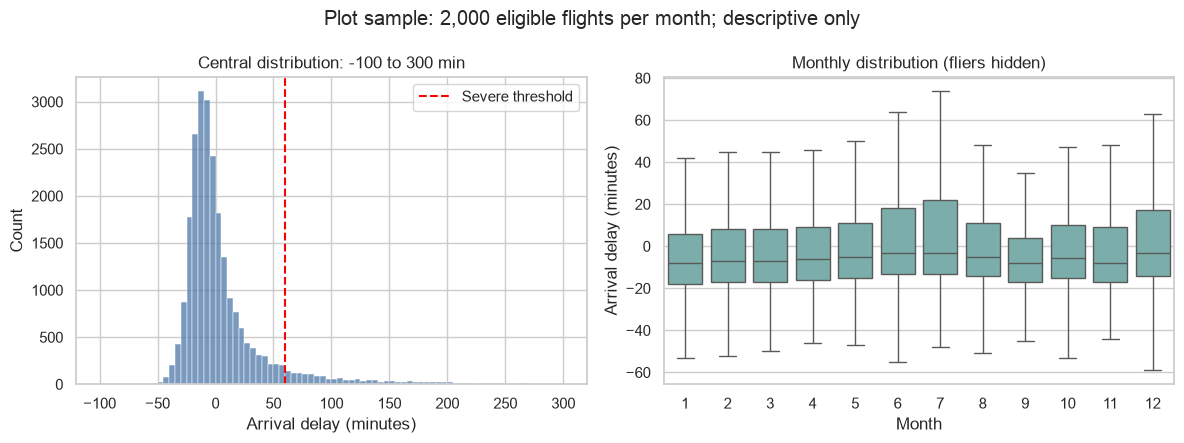

,group,eligible_flights,mean,median,p90,p95,p99,minimum,maximum
0,1,522269,3.756614,-8.0,37.0,74.0,205.0,-87.0,3282.0
1,2,496476,5.718929,-7.0,44.0,84.0,212.0,-91.0,3407.0
2,3,592301,5.451542,-7.0,41.0,81.0,213.0,-83.0,3275.0
3,4,577730,5.664272,-6.0,40.0,78.0,203.0,-76.0,2575.0
4,5,597574,10.188485,-4.0,52.0,95.0,228.0,-128.0,3241.0
5,6,599472,15.592393,-3.0,67.0,114.0,254.0,-78.0,2794.0
6,7,612811,17.346069,-3.0,72.0,124.0,279.0,-83.0,2557.0
7,8,593733,9.242210,-5.0,49.0,91.0,227.0,-77.0,3147.0
8,9,558328,2.316248,-8.0,31.0,64.0,180.0,-78.0,4336.0
9,10,601570,5.585546,-6.0,38.0,72.0,188.0,-76.0,3500.0


In [7]:
plot_sample = pd.read_csv(table_path(TABLE_FOLDER, "eda_plot_sample"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Only the visual window is cropped; no source rows or stored delays are changed.
sns.histplot(data=plot_sample, x="arrival_delay_minutes",
             bins=np.arange(-100, 305, 5), ax=axes[0], color="#4C78A8")
axes[0].axvline(60, color="red", linestyle="--", label="Severe threshold")
axes[0].set(xlabel="Arrival delay (minutes)", title="Central distribution: -100 to 300 min")
axes[0].legend()
sns.boxplot(data=plot_sample, x="month", y="arrival_delay_minutes",
            showfliers=False, ax=axes[1], color="#72B7B2")
axes[1].set(xlabel="Month", ylabel="Arrival delay (minutes)", title="Monthly distribution (fliers hidden)")
fig.suptitle("Plot sample: 2,000 eligible flights per month; descriptive only")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER / "arrival_delay_distribution.png", dpi=160)
plt.show()

monthly_quantiles = pd.read_csv(table_path(TABLE_FOLDER, "monthly_delay_distribution"))
display(monthly_quantiles)

The equal-sized monthly sample helps keep plots responsive. It is not a representative weighting of full-year flight volume, so we do not calculate headline rates from it. The full-data distribution table retains the extreme minimum/maximum and quantiles; the cropped histogram and hidden boxplot fliers are visual choices only.

## F. Confirm that cleaning preserved the data

In [8]:
reconciliation = pd.read_csv(table_path(TABLE_FOLDER, "final_row_reconciliation"))
display(reconciliation[["month", "raw_rows", "cleaned_rows", "enriched_rows", "ml_rows", "excluded_from_ml"]])
assert reconciliation["raw_rows"].equals(reconciliation["cleaned_rows"])
assert reconciliation["raw_rows"].equals(reconciliation["enriched_rows"])
assert (reconciliation["ml_rows"] + reconciliation["excluded_from_ml"]).equals(reconciliation["raw_rows"])
print("All source rows retained; only target-ineligible rows excluded from ML.")

,month,raw_rows,cleaned_rows,enriched_rows,ml_rows,excluded_from_ml
0,1,539747,539747,539747,522269,17478
1,2,504884,504884,504884,496476,8408
2,3,600872,600872,600872,592301,8571
3,4,583950,583950,583950,577730,6220
4,5,605648,605648,605648,597574,8074
5,6,611575,611575,611575,599472,12103
6,7,631428,631428,631428,612811,18617
7,8,602378,602378,602378,593733,8645
8,9,562439,562439,562439,558328,4111
9,10,605844,605844,605844,601570,4274


All source rows retained; only target-ineligible rows excluded from ML.


## G. Full-year operational EDA

Rates need a denominator: severe/on-time rates use completed, non-diverted flights with a known arrival delay; cancellation/diversion rates use all scheduled records. Group comparisons describe associations and may reflect route mix, schedules, seasonality, and other unmeasured factors.

## 2. Load the prepared EDA tables

Each CSV is a normal pandas DataFrame. The tables contain the same results produced from all 7,001,619 raw flight rows.

In [9]:
overall = pd.read_csv(table_path(TABLE_FOLDER, "overall_summary"))
monthly = pd.read_csv(table_path(TABLE_FOLDER, "monthly_performance"))
time_bands = pd.read_csv(table_path(TABLE_FOLDER, "departure_time_band_performance"))
airlines = pd.read_csv(table_path(TABLE_FOLDER, "airline_performance"))
routes = pd.read_csv(table_path(TABLE_FOLDER, "route_performance"))
causes = pd.read_csv(table_path(TABLE_FOLDER, "delay_cause_summary"))

print("Tables loaded successfully")
print("Months:", len(monthly), "| Airlines:", len(airlines), "| Routes:", len(routes))

Tables loaded successfully
Months: 12 | Airlines: 14 | Routes: 6938


## 3. Overall performance

A severe delay means an arrival delay of **more than 60 minutes**. Cancelled, diverted, and unknown arrival outcomes are not labelled as severe or non-severe.

In [10]:
# Change the two-column table into an easy metric lookup.
metrics = overall.set_index("metric")["value"]

overall_display = pd.DataFrame({
    "Measure": [
        "Scheduled flights",
        "Cancelled flights",
        "Diverted flights",
        "Average arrival delay (minutes)",
        "Median arrival delay (minutes)",
        "Severe-delay rate",
        "On-time/early rate",
    ],
    "Value": [
        f"{metrics['total_flights']:,.0f}",
        f"{metrics['cancelled_flights']:,.0f}",
        f"{metrics['diverted_flights']:,.0f}",
        f"{metrics['average_arrival_delay_minutes']:.2f}",
        f"{metrics['median_arrival_delay_minutes']:.2f}",
        f"{metrics['severe_delay_rate']:.2%}",
        f"{metrics['on_time_early_rate']:.2%}",
    ],
})
overall_display

,Measure,Value
0,Scheduled flights,"7,001,619"
1,Cancelled flights,"102,876"
2,Diverted flights,"19,258"
3,Average arrival delay (minutes),8.50
4,Median arrival delay (minutes),-6.00
5,Severe-delay rate,8.04%
6,On-time/early rate,62.43%


## 4. Monthly flight volume and severe delays

The bars show how many flights were scheduled. The line shows the percentage of eligible flights that arrived more than 60 minutes late.

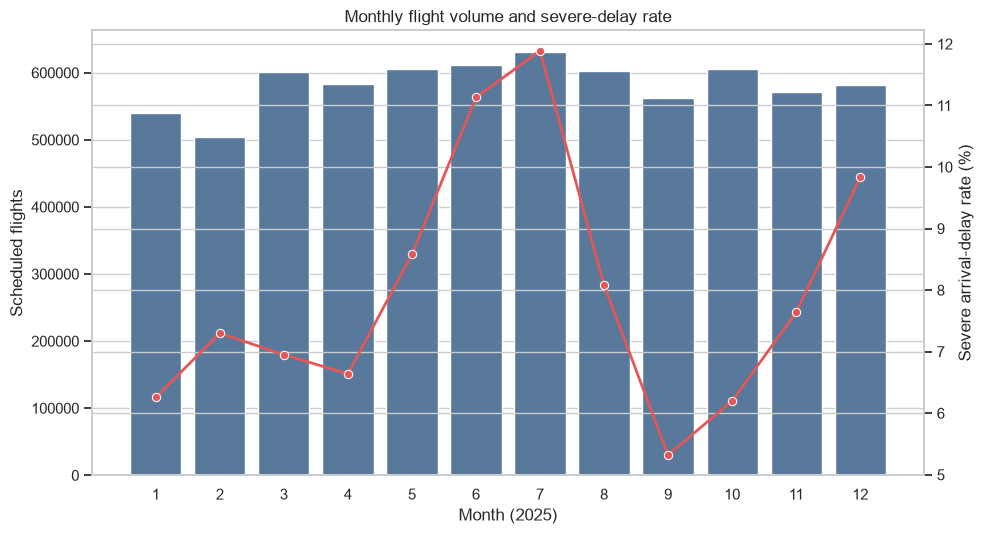

In [11]:
monthly = monthly.sort_values("month").copy()
monthly["severe_delay_percent"] = np.round(monthly["severe_delay_rate"] * 100, 2)

fig, ax1 = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=monthly, x="month", y="total_flights", color="#4C78A8", ax=ax1)
ax1.set(xlabel="Month (2025)", ylabel="Scheduled flights")

ax2 = ax1.twinx()
sns.lineplot(data=monthly, x=np.arange(12), y="severe_delay_percent",
             color="#E45756", marker="o", linewidth=2, ax=ax2)
ax2.set_ylabel("Severe arrival-delay rate (%)")
plt.title("Monthly flight volume and severe-delay rate")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER / "monthly_volume_and_severe_delay.png", dpi=160)
plt.show()

In [12]:
worst_month = monthly.loc[monthly["severe_delay_rate"].idxmax()]
print(
    f"Month {int(worst_month['month'])} had the highest severe-delay rate: "
    f"{worst_month['severe_delay_rate']:.2%}."
)

Month 7 had the highest severe-delay rate: 11.89%.


## 5. Does departure time matter?

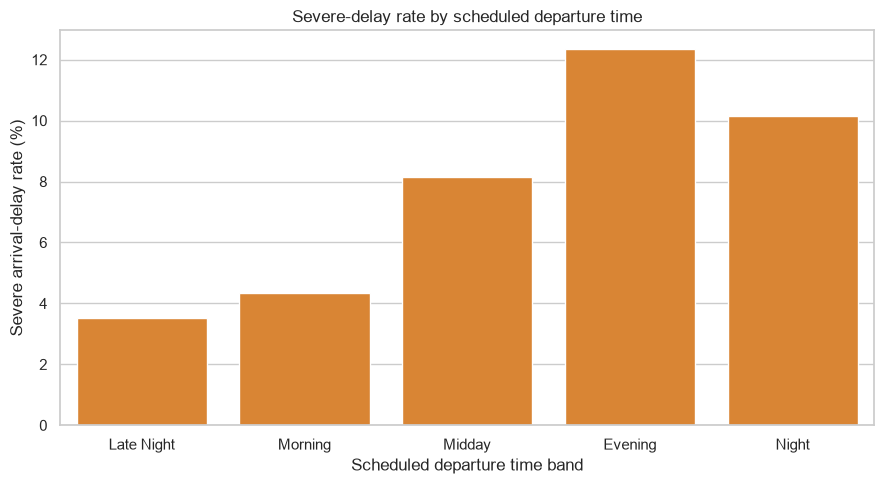

In [13]:
band_order = ["Late Night", "Morning", "Midday", "Evening", "Night"]
time_bands["severe_delay_percent"] = np.round(time_bands["severe_delay_rate"] * 100, 2)

plt.figure(figsize=(9, 5))
sns.barplot(data=time_bands, x="departure_time_band", y="severe_delay_percent",
            order=band_order, color="#F58518")
plt.xlabel("Scheduled departure time band")
plt.ylabel("Severe arrival-delay rate (%)")
plt.title("Severe-delay rate by scheduled departure time")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "severe_delay_by_departure_band.png", dpi=160)
plt.show()

In [14]:
worst_band = time_bands.loc[time_bands["severe_delay_rate"].idxmax()]
print(
    f"{worst_band['departure_time_band']} flights had the highest severe-delay rate: "
    f"{worst_band['severe_delay_rate']:.2%}."
)

Evening flights had the highest severe-delay rate: 12.34%.


## 6. Compare airlines

Only airlines with at least 10,000 flights are included, so a very small airline cannot rank first because of only a few unusual flights.

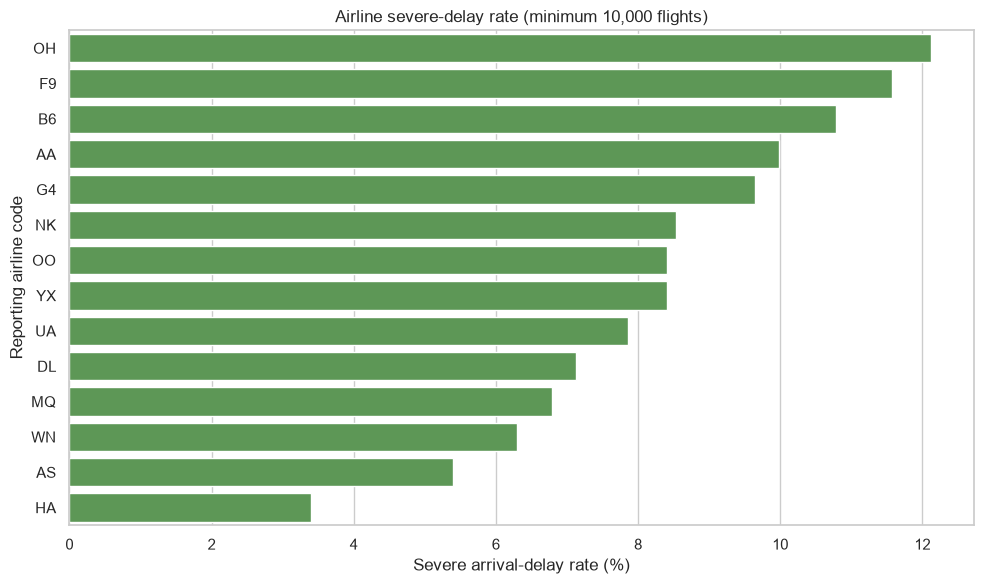

In [15]:
large_airlines = airlines[airlines["total_flights"] >= settings["ranking_thresholds"]["airline_min_flights"]].copy()
large_airlines["severe_delay_percent"] = np.round(large_airlines["severe_delay_rate"] * 100, 2)
large_airlines = large_airlines.sort_values("severe_delay_percent", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=large_airlines, x="severe_delay_percent", y="reporting_airline",
            color="#54A24B")
plt.xlabel("Severe arrival-delay rate (%)")
plt.ylabel("Reporting airline code")
plt.title("Airline severe-delay rate (minimum 10,000 flights)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "airline_severe_delay_rate.png", dpi=160)
plt.show()

In [16]:
worst_airline = large_airlines.iloc[0]
print(
    f"Airline {worst_airline['reporting_airline']} had the highest severe-delay rate: "
    f"{worst_airline['severe_delay_rate']:.2%}."
)

Airline OH had the highest severe-delay rate: 12.12%.


## 7. Compare busy routes

The same fairness idea is used here: only routes with at least 1,000 flights are compared.

In [17]:
busy_routes = routes[routes["total_flights"] >= settings["ranking_thresholds"]["route_min_flights"]].copy()
busy_routes = busy_routes.sort_values("severe_delay_rate", ascending=False)

top_routes = busy_routes[["route", "total_flights", "severe_delay_rate"]].head(10).copy()
top_routes["severe_delay_rate"] = top_routes["severe_delay_rate"].map(lambda value: f"{value:.2%}")
top_routes

,route,total_flights,severe_delay_rate
155,ASE-DFW,1178,19.15%
1587,DCA-SAV,1074,18.53%
1541,DCA-HPN,1359,18.40%
2816,HPN-DCA,1359,17.68%
5543,RDU-EWR,1848,16.96%
1601,DCA-TYS,1033,16.91%
2876,IAD-EWR,1499,16.87%
1910,DFW-MSN,1094,16.62%
4735,ORD-EWR,5990,16.56%
208,ATL-EWR,6105,16.51%


## 8. Which reported causes contributed the most delay minutes?

These cause fields are useful for description, but they happen after the delay and should not be used to predict a delay before departure.

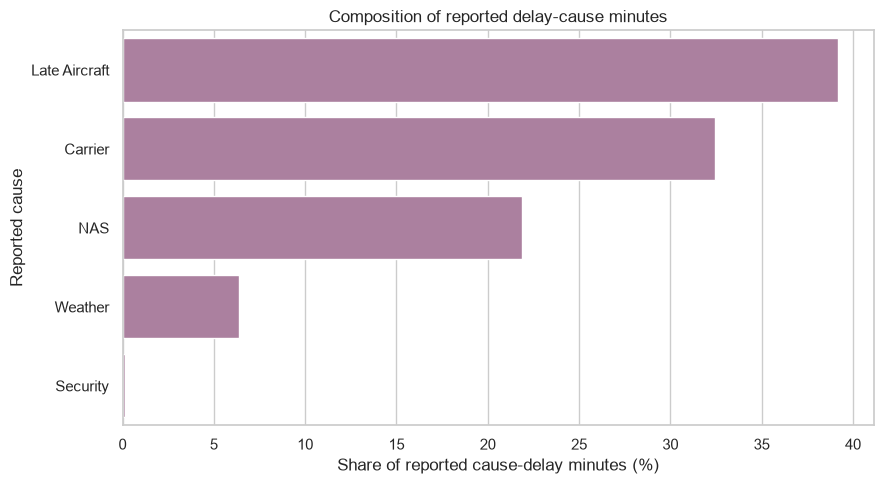

In [18]:
causes["share_percent"] = np.round(causes["share_of_reported_cause_minutes"] * 100, 2)
causes = causes.sort_values("share_percent", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=causes, x="share_percent", y="cause", color="#B279A2")
plt.xlabel("Share of reported cause-delay minutes (%)")
plt.ylabel("Reported cause")
plt.title("Composition of reported delay-cause minutes")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "reported_delay_cause_share.png", dpi=160)
plt.show()

## 9. Final findings

This last cell calculates the conclusions from the tables instead of typing the answers manually.

In [19]:
worst_route = busy_routes.iloc[0]
top_cause = causes.iloc[0]

findings = [
    f"1. Month {int(worst_month['month'])} had the highest severe-delay rate ({worst_month['severe_delay_rate']:.2%}).",
    f"2. {worst_band['departure_time_band']} departures had the highest severe-delay rate ({worst_band['severe_delay_rate']:.2%}).",
    f"3. Airline {worst_airline['reporting_airline']} ranked highest among airlines with at least 10,000 flights ({worst_airline['severe_delay_rate']:.2%}).",
    f"4. Route {worst_route['route']} ranked highest among routes with at least 1,000 flights ({worst_route['severe_delay_rate']:.2%}).",
    f"5. {top_cause['cause']} made up the largest share of reported cause-delay minutes ({top_cause['share_of_reported_cause_minutes']:.2%}).",
]

print("\n".join(findings))

1. Month 7 had the highest severe-delay rate (11.89%).
2. Evening departures had the highest severe-delay rate (12.34%).
3. Airline OH ranked highest among airlines with at least 10,000 flights (12.12%).
4. Route ASE-DFW ranked highest among routes with at least 1,000 flights (19.15%).
5. Late Aircraft made up the largest share of reported cause-delay minutes (39.19%).


## 10. Airports, routes, and delay distributions

Airport rankings use at least 5,000 scheduled flights. Show both flight counts and eligible counts: a percentage without volume can be misleading. These are descriptive rankings of the observed year, not a causal comparison of airport quality.

,origin,total_flights,target_eligible_flights,average_departure_delay_minutes,cancellation_rate
19,ASE,7685,7207,31.551091,0.057645
172,JAC,6386,6237,21.573856,0.014093
52,BTV,6551,6319,20.909077,0.031293
61,CHA,5140,4994,20.820758,0.025292
337,TVC,5196,5069,20.373525,0.021555
255,PIA,5435,5301,19.585687,0.022999
90,DFW,315854,306185,19.156110,0.027563
249,PBI,30785,30181,19.149103,0.015495
294,SBN,7848,7676,18.924046,0.018603
125,FWA,6614,6468,18.514484,0.018748


,destination,total_flights,target_eligible_flights,average_arrival_delay_minutes,severe_delay_rate
301,SFB,10497,10425,28.184460,0.155779
19,ASE,7684,7079,20.912700,0.137308
257,PIE,9415,9317,19.861007,0.124074
337,TVC,5194,5090,16.960118,0.108841
306,SHV,5954,5799,16.639593,0.113468
341,TYS,13265,12970,16.377178,0.114341
111,EWR,120344,116774,15.888092,0.129284
86,DCA,142554,136407,15.747623,0.109965
85,DAY,7933,7737,15.734910,0.116712
294,SBN,7848,7689,15.419170,0.114709


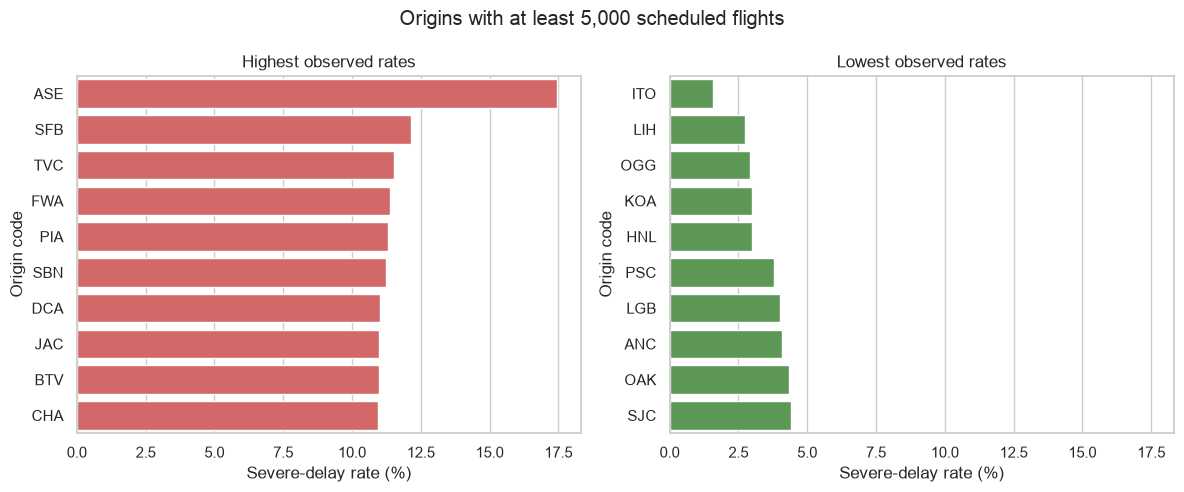

Exact full-year distributions for the 10 busiest routes and origins:


,group,eligible_flights,mean,median,p90,p95,p99,minimum,maximum
0,BOS-DCA,8813,11.406672,-6.0,62.8,107.0,219.88,-59.0,1781.0
1,DCA-BOS,8829,12.227546,-7.0,72.0,116.0,237.88,-62.0,1127.0
2,HNL-OGG,10607,1.184218,-3.0,15.0,29.0,82.94,-32.0,449.0
3,JFK-LAX,10157,2.314857,-11.0,44.0,90.0,240.44,-79.0,1269.0
4,LAX-JFK,10110,2.804451,-13.0,48.0,99.0,289.91,-72.0,1448.0
5,LAX-SFO,10787,7.953741,-5.0,52.0,87.0,168.14,-42.0,1321.0
6,LGA-ORD,11206,18.826165,-3.0,85.0,144.0,307.90,-58.0,1670.0
7,OGG-HNL,10595,0.684663,-4.0,16.0,31.0,88.00,-35.0,527.0
8,ORD-LGA,11176,18.500537,-3.0,81.0,133.0,298.25,-58.0,1344.0
9,SFO-LAX,10795,6.444836,-6.0,43.6,78.0,174.06,-43.0,1513.0


,group,eligible_flights,mean,median,p90,p95,p99,minimum,maximum
0,ATL,309064,10.663445,-4.0,51.0,90.0,212.00,-61.0,2052.0
1,CLT,191629,10.218370,-4.0,54.0,95.0,213.00,-64.0,1339.0
2,DEN,314281,11.145379,-3.0,54.0,93.0,209.00,-79.0,2241.0
3,DFW,306185,14.935696,-3.0,66.0,111.0,245.00,-63.0,1756.0
4,LAS,181901,4.753058,-7.0,40.0,72.0,177.00,-76.0,2303.0
5,LAX,188578,2.627385,-9.0,35.0,71.0,195.23,-128.0,2184.0
6,MCO,157950,10.920538,-5.0,57.0,104.0,237.00,-67.0,2096.0
7,ORD,320418,12.843514,-4.0,62.0,109.0,245.00,-78.0,2337.0
8,PHX,194840,5.259705,-6.0,37.0,70.0,176.00,-77.0,1866.0
9,SEA,162971,4.761559,-4.0,37.0,63.0,157.00,-87.0,1785.0


Airline mean/median/quantiles:


,group,eligible_flights,mean,median,p90,p95,p99,minimum,maximum
0,AA,952841,13.694796,-5.0,60.0,109.0,283.00,-91.0,4336.0
1,AS,241927,4.802502,-4.0,38.0,64.0,160.00,-87.0,985.0
2,B6,226703,10.951412,-6.0,65.0,110.0,242.00,-83.0,1706.0
3,DL,1012427,5.692303,-8.0,42.0,82.0,220.00,-83.0,1386.0
4,F9,194192,14.835452,-5.0,70.0,119.0,291.00,-82.0,1431.0
5,G4,129892,13.011040,-6.0,58.0,107.0,281.09,-83.0,1537.0
6,HA,79335,6.777311,0.0,25.0,45.0,144.00,-97.0,1323.0
7,MQ,291835,6.235880,-5.0,42.0,76.0,182.00,-65.0,2955.0
8,NK,191191,6.599871,-8.0,51.0,96.0,220.00,-128.0,1245.0
9,OH,236682,17.321888,-5.0,74.0,131.0,300.00,-64.0,2420.0


In [20]:
origins = pd.read_csv(table_path(TABLE_FOLDER, "origin_airport_performance"))
destinations = pd.read_csv(table_path(TABLE_FOLDER, "destination_airport_performance"))
origin_limit = settings["ranking_thresholds"]["airport_min_flights"]
origin_rank = origins.loc[origins["total_flights"].ge(origin_limit)].copy()
origin_rank["severe_percent"] = origin_rank["severe_delay_rate"] * 100
display(origin_rank.nlargest(10, "average_departure_delay_minutes")[
    ["origin", "total_flights", "target_eligible_flights", "average_departure_delay_minutes", "cancellation_rate"]])
display(destinations.loc[destinations["total_flights"].ge(origin_limit)].nlargest(
    10, "average_arrival_delay_minutes")[
    ["destination", "total_flights", "target_eligible_flights", "average_arrival_delay_minutes", "severe_delay_rate"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=origin_rank.nlargest(10, "severe_percent"), y="origin", x="severe_percent",
            ax=axes[0], color="#E45756")
sns.barplot(data=origin_rank.nsmallest(10, "severe_percent"), y="origin", x="severe_percent",
            ax=axes[1], color="#54A24B")
maximum = origin_rank["severe_percent"].max() * 1.05
for ax in axes:
    ax.set(xlim=(0, maximum), xlabel="Severe-delay rate (%)", ylabel="Origin code")
axes[0].set_title("Highest observed rates")
axes[1].set_title("Lowest observed rates")
fig.suptitle("Origins with at least 5,000 scheduled flights")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER / "origin_airport_comparison.png", dpi=160)
plt.show()

print("Exact full-year distributions for the 10 busiest routes and origins:")
display(pd.read_csv(table_path(TABLE_FOLDER, "busy_route_delay_distribution")))
display(pd.read_csv(table_path(TABLE_FOLDER, "busy_origin_delay_distribution")))
print("Airline mean/median/quantiles:")
display(pd.read_csv(table_path(TABLE_FOLDER, "airline_delay_distribution")))

## 11. Do cancellations vary by airport and month?

This is a non-trivial reshape: the pipeline groups all flight records by month and origin, then this cell pivots the rates into an airport-by-month matrix. Each rate uses that airport-month's scheduled flights as its denominator. We display the 10 busiest origins by full-year volume. A missing cell would be left blank rather than treated as zero.

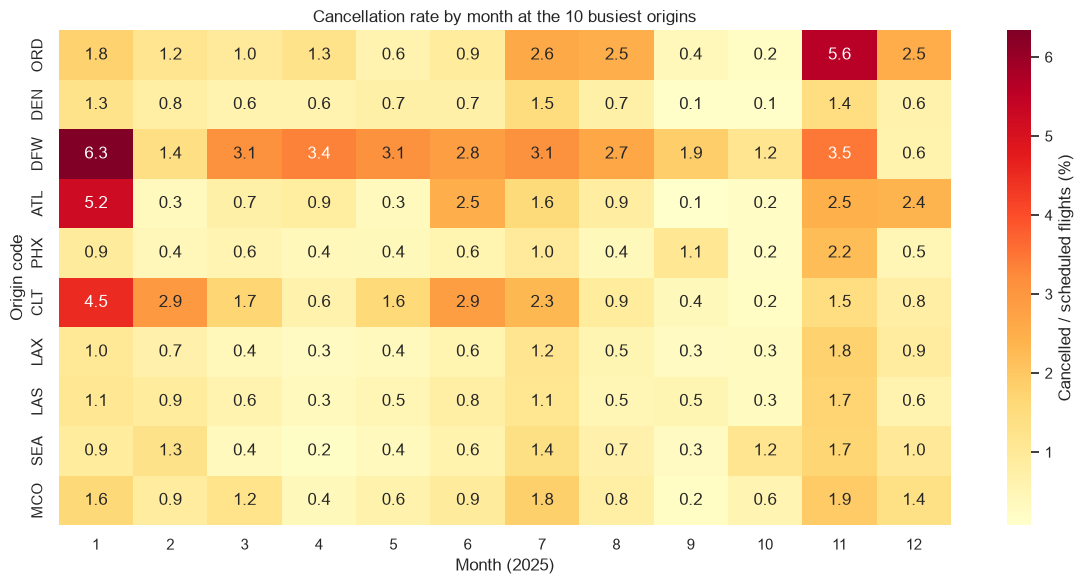

The highest displayed airport-month cancellation rate was DFW in month 1: 6.34% (1,592 / 25,124 flights).


,cancellation_code,cancelled_flights
0,A,20903
1,B,63404
2,C,18519
3,D,50


In [21]:
airport_month = pd.read_csv(table_path(TABLE_FOLDER, "airport_month_cancellations"))
busiest = origins.nlargest(10, "total_flights")["origin"]
cancellation_matrix = airport_month.loc[airport_month["origin"].isin(busiest)].pivot(
    index="origin", columns="month", values="cancellation_rate"
).reindex(busiest)
plt.figure(figsize=(12, 6))
sns.heatmap(cancellation_matrix * 100, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "Cancelled / scheduled flights (%)"})
plt.title("Cancellation rate by month at the 10 busiest origins")
plt.xlabel("Month (2025)")
plt.ylabel("Origin code")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER / "airport_month_cancellations.png", dpi=160)
plt.show()

selected = airport_month.loc[airport_month["origin"].isin(busiest)]
peak = selected.loc[selected["cancellation_rate"].idxmax()]
print(f"The highest displayed airport-month cancellation rate was {peak['origin']} "
      f"in month {int(peak['month'])}: {peak['cancellation_rate']:.2%} "
      f"({int(peak['cancelled_flights']):,} / {int(peak['total_flights']):,} flights).")
display(pd.read_csv(table_path(TABLE_FOLDER, "cancellation_code_counts")))

## 12. Remaining time comparisons and final handoff

In [22]:
for name in ["day_of_week_performance", "departure_hour_performance",
             "weekend_performance", "season_performance"]:
    print(name.replace("_", " ").title())
    table = pd.read_csv(table_path(TABLE_FOLDER, name))
    display(table[[table.columns[0], "total_flights", "target_eligible_flights",
                   "average_arrival_delay_minutes", "severe_delay_rate", "cancellation_rate"]])

print("Cleaning complete:", f"{reconciliation['cleaned_rows'].sum():,}", "operational rows.")
print("Next: open 02_feature_engineering.ipynb.")


Day Of Week Performance


,day_of_week,total_flights,target_eligible_flights,average_arrival_delay_minutes,severe_delay_rate,cancellation_rate
0,1,1050150,1031857,10.151053,0.086676,0.014842
1,2,945648,931999,4.105690,0.063775,0.011797
2,3,966102,951705,4.996305,0.067324,0.012425
3,4,1040825,1021742,9.552520,0.081829,0.015309
4,5,1044333,1024839,9.487831,0.082576,0.016043
5,6,906399,890640,6.911642,0.074555,0.014644
6,7,1048162,1026702,13.451970,0.102681,0.017334


Departure Hour Performance


,scheduled_dep_hour,total_flights,target_eligible_flights,average_arrival_delay_minutes,severe_delay_rate,cancellation_rate
0,0,11257,11076,0.696551,0.050108,0.014125
1,1,3440,3393,1.690245,0.051872,0.012500
2,2,1315,1299,2.434950,0.063895,0.012167
3,3,740,732,3.333333,0.079235,0.010811
4,4,303,298,-5.144295,0.036913,0.016502
5,5,198233,194931,-2.478374,0.033771,0.015023
6,6,482290,474704,-2.079494,0.033760,0.013838
7,7,508195,501217,-0.509380,0.038361,0.011364
8,8,485360,478909,0.590164,0.043240,0.010914
9,9,395691,390739,1.703544,0.047446,0.010031


Weekend Performance


,is_weekend,total_flights,target_eligible_flights,average_arrival_delay_minutes,severe_delay_rate,cancellation_rate
0,0,5047058,4962142,7.766737,0.076818,0.014154
1,1,1954561,1917342,10.413870,0.089616,0.016086


Season Performance


,season,total_flights,target_eligible_flights,average_arrival_delay_minutes,severe_delay_rate,cancellation_rate
0,Fall,1738833,1715194,4.776215,0.063838,0.011666
1,Spring,1790470,1767605,7.122489,0.073997,0.010154
2,Summer,1845381,1806016,14.099803,0.103873,0.017174
3,Winter,1626935,1590669,7.707605,0.078659,0.020110


Cleaning complete: 7,001,619 operational rows.
Next: open 02_feature_engineering.ipynb.


## Conclusions, limitations, and connection to ML

The calculated findings above answer when, where, and for which carriers delays are concentrated. Their practical implication is to investigate schedule/time, airline, and route as candidate predictors; they do not establish causality or guarantee predictive performance.

- Mean and median are both reported because a small number of very long delays shift the average.
- Minimum-volume filters reduce tiny-group instability but do not make rankings statistically significant.
- Full-year EDA includes future holdout months. Do not repeatedly tune models to their observed outcomes; later evaluation must keep preprocessing/training within the frozen dates.
- The future target is conditional on completed, non-diverted flights with known outcomes. This is not a cancellation model.
- Current airport metadata cannot establish historical airport names or operations in 2025.
- Only 2025 is covered; no year-over-year or international generalization is claimed.

The short cleaning log is in `reports/cleaning_log.md`. Full transformation and storage results are in `reports/transformation_report.md`. Warehouse construction, ML fitting, and Power BI are the next project stages.